# STOP-Collapse in World Model Navigation

**Finding:** When using R2-Dreamer for Habitat ObjectNav with STOP as a terminal action, the agent collapses to always calling STOP, regardless of reward shaping, entropy bonuses, or gradient fixes.

This notebook documents 5 training runs that each attempt a different fix, compares them over the same step range, and analyzes why all of them fail.

### Key Terms

- **Episode**: One full attempt at the task. The agent spawns at a random position in a house and takes actions (steps) until the episode ends.
- **Step**: One action taken by the agent (STOP, MOVE_FORWARD, TURN_LEFT, or TURN_RIGHT).
- **Episode length**: How many steps the agent took before the episode ended. Length = 500 means the agent used all available steps.
- **Length-1 episode**: The agent called STOP as its very first action. Since STOP triggers `done=True` (episode termination), the episode ends immediately — the agent never moved.
- **Prefill (5000 steps)**: Before training, the agent takes 5000 random actions to fill the replay buffer. No learning happens during prefill. The step counter in the training loop starts at 0 **after** prefill.
- **Training (step 0+)**: The learned policy takes over. Step 0 in the plots is when training begins.

### Runs Overview

Each run adds one fix on top of the previous. All runs were killed manually once collapse was observed, so they ran for different durations. **All plots below are clipped to steps 0–7000 for fair comparison.**

| Run | Configuration | What Changed |
|-----|--------------|--------|
| 1 | Default (`act_entropy=3e-4`) | Baseline — low entropy |
| 2 | `act_entropy=3e-2` | 100× higher entropy bonus |
| 3 | + `stop_penalty=-1.0` | Negative reward for STOP without success |
| 4 | + No-STOP prefill | Exclude STOP from prefill random actions |
| 5 | + Imagination weight fix | First imagined step always has weight=1.0 |

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})

LOG_DIR = Path("../../../output/r2dreamer-habitat-baseline/stop-collapse-logs")
MAX_STEP = 7000  # clip all runs to this range for fair comparison

In [2]:
def parse_log(path, max_step=None):
    """Extract episode lengths and loss values from training stdout."""
    episodes = []
    losses = []

    ep_pat = re.compile(
        r"\[step\s+(\d+)\] episode (\d+): "
        r"reward=([\-\d.]+) success=([\d.]+) "
        r"spl=([\d.]+) steps=(\d+)"
    )
    loss_pat = re.compile(
        r"\[step\s+(\d+)/\d+\] "
        r"total=([\-\d.]+) dyn=([\-\d.]+) "
        r"rew=([\-\d.]+) policy=([\-\d.]+) fps=(\d+)"
    )

    text = Path(path).read_text()
    for m in ep_pat.finditer(text):
        step = int(m.group(1))
        if max_step and step > max_step:
            continue
        episodes.append({
            "step": step,
            "episode": int(m.group(2)),
            "reward": float(m.group(3)),
            "success": float(m.group(4)),
            "spl": float(m.group(5)),
            "ep_steps": int(m.group(6)),
        })
    for m in loss_pat.finditer(text):
        step = int(m.group(1))
        if max_step and step > max_step:
            continue
        losses.append({
            "step": step,
            "total": float(m.group(2)),
            "dyn": float(m.group(3)),
            "rew": float(m.group(4)),
            "policy": float(m.group(5)),
            "fps": int(m.group(6)),
        })
    return episodes, losses

In [3]:
runs = {
    "Run 1: Default (ent=3e-4)": "run1_no_penalty.log",
    "Run 2: Higher entropy (3e-2)": "run2_entropy_3e2.log",
    "Run 3: + Stop penalty (-1.0)": "run3_stop_penalty.log",
    "Run 4: + No-STOP prefill": "run4_no_stop_prefill.log",
    "Run 5: + Weight fix": "run5_weight_fix.log",
}

data = {}
for name, fname in runs.items():
    path = LOG_DIR / fname
    if path.exists():
        eps, losses = parse_log(path, max_step=MAX_STEP)
        data[name] = {"episodes": eps, "losses": losses}
        n_ep = len(eps)
        n_loss = len(losses)
        max_s = eps[-1]["step"] if eps else 0
        print(f"{name}: {n_ep} episodes, {n_loss} loss logs (clipped to step {MAX_STEP})")
    else:
        print(f"{name}: NOT FOUND")

print(f"\nNote: episode counts differ because shorter episodes = more episodes per step.")
print(f"A run with mostly length-1 episodes has ~1 episode per step.")
print(f"A run with length-4 episodes has ~1 episode per 4 steps.")

Run 1: Default (ent=3e-4): 1648 episodes, 28 loss logs (clipped to step 7000)
Run 2: Higher entropy (3e-2): 1816 episodes, 28 loss logs (clipped to step 7000)
Run 3: + Stop penalty (-1.0): 2318 episodes, 28 loss logs (clipped to step 7000)
Run 4: + No-STOP prefill: 4629 episodes, 28 loss logs (clipped to step 7000)
Run 5: + Weight fix: 4496 episodes, 28 loss logs (clipped to step 7000)

Note: episode counts differ because shorter episodes = more episodes per step.
A run with mostly length-1 episodes has ~1 episode per step.
A run with length-4 episodes has ~1 episode per 4 steps.


## 1. Episode Length Over Training

Each dot is one episode. The red line is a rolling average over 50 episodes. A healthy agent should maintain episode lengths >> 1. Collapse to STOP shows as the red line dropping to 1.

All plots share the same x-axis (0–7000 steps) and y-axis (0–60) for direct comparison.

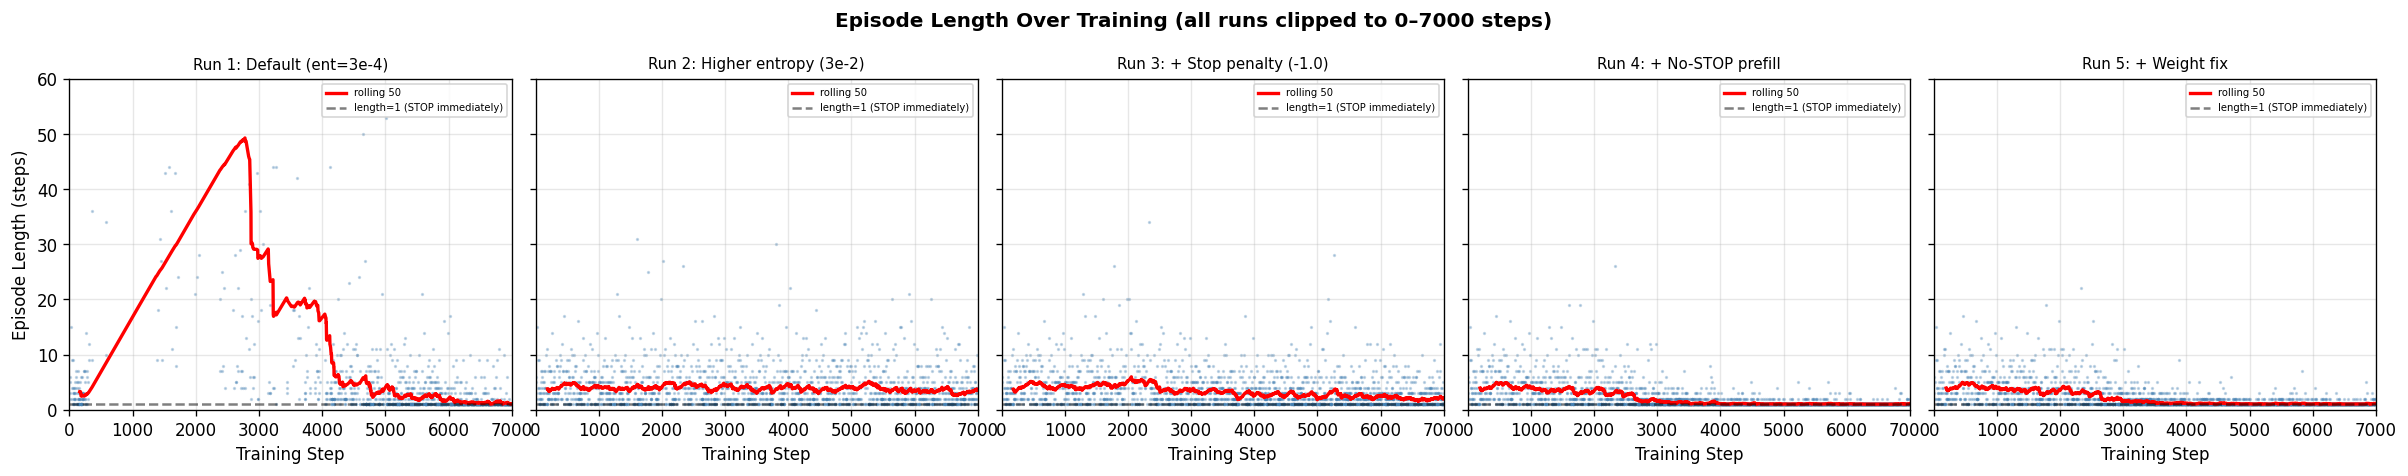

In [4]:
fig, axes = plt.subplots(1, len(data), figsize=(4 * len(data), 4), sharey=True, sharex=True)
if len(data) == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, data.items()):
    eps = d["episodes"]
    if not eps:
        continue
    steps = [e["step"] for e in eps]
    lengths = [e["ep_steps"] for e in eps]

    ax.scatter(steps, lengths, s=1, alpha=0.3, color="steelblue")
    # Rolling mean over 50 episodes
    if len(lengths) >= 50:
        rolling = pd.Series(lengths).rolling(50).mean().values
        ax.plot(steps, rolling, color="red", linewidth=2, label="rolling 50")
    ax.set_xlabel("Training Step")
    ax.set_title(name, fontsize=9)
    ax.set_xlim(0, MAX_STEP)
    ax.set_ylim(0, 60)
    ax.axhline(y=1, color="black", linestyle="--", alpha=0.5, label="length=1 (STOP immediately)")
    ax.legend(fontsize=6, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Episode Length (steps)")
fig.suptitle("Episode Length Over Training (all runs clipped to 0–7000 steps)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Episode Length Distribution

Histogram of episode lengths across each run (clipped to 0–7000 steps). The bar at length=1 shows how many episodes ended on the first step (agent called STOP immediately).

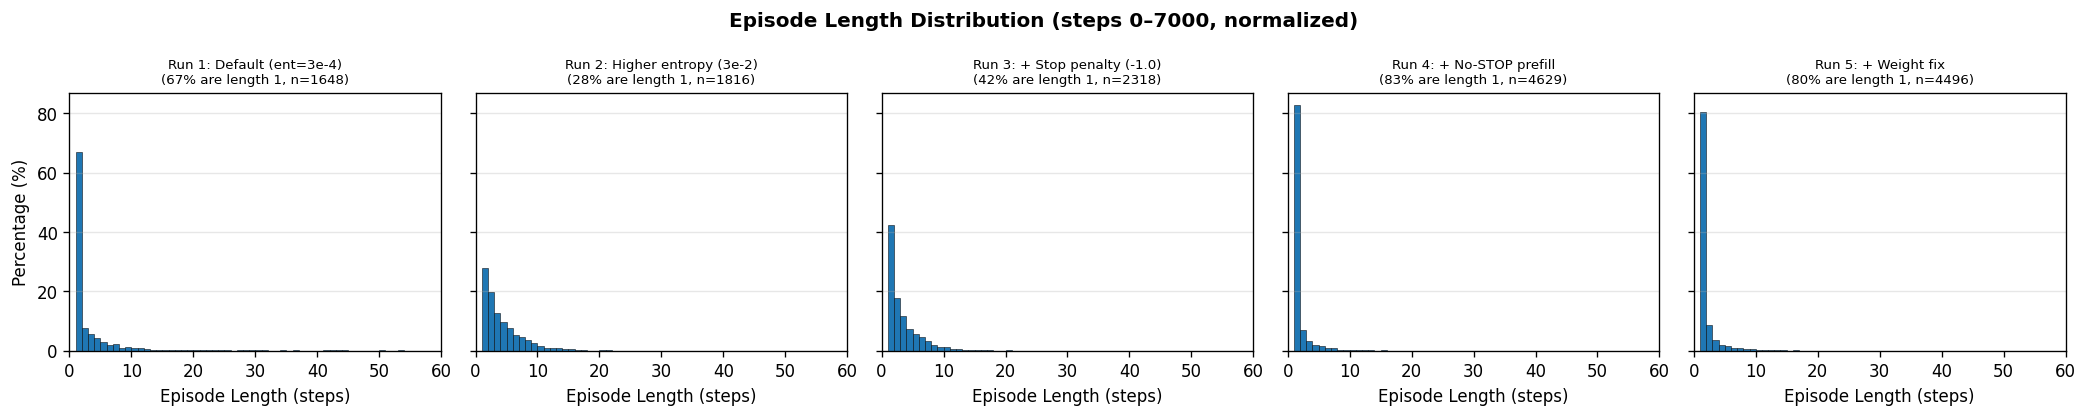

In [5]:
fig, axes = plt.subplots(1, len(data), figsize=(3.5 * len(data), 3.5), sharey=True)
if len(data) == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, data.items()):
    eps = d["episodes"]
    if not eps:
        continue
    lengths = [e["ep_steps"] for e in eps]
    n_total = len(lengths)
    n_len1 = sum(1 for l in lengths if l == 1)
    pct_1 = n_len1 / n_total * 100

    ax.hist(lengths, bins=range(1, 62), edgecolor="black", linewidth=0.3,
            weights=np.ones(len(lengths)) / len(lengths) * 100)
    ax.set_xlabel("Episode Length (steps)")
    ax.set_title(f"{name}\n({pct_1:.0f}% are length 1, n={n_total})", fontsize=8)
    ax.set_xlim(0, 60)
    ax.grid(True, alpha=0.3, axis="y")

axes[0].set_ylabel("Percentage (%)")
fig.suptitle("Episode Length Distribution (steps 0–7000, normalized)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Policy Loss Over Training

The policy loss includes both the advantage-weighted policy gradient and the entropy bonus. In a healthy agent, this loss should be clearly non-zero — it means the actor is receiving learning signal.

- **Near zero** → the actor is getting almost no gradient (dead gradient problem)
- **Negative** → the entropy bonus dominates (pushing toward random exploration)

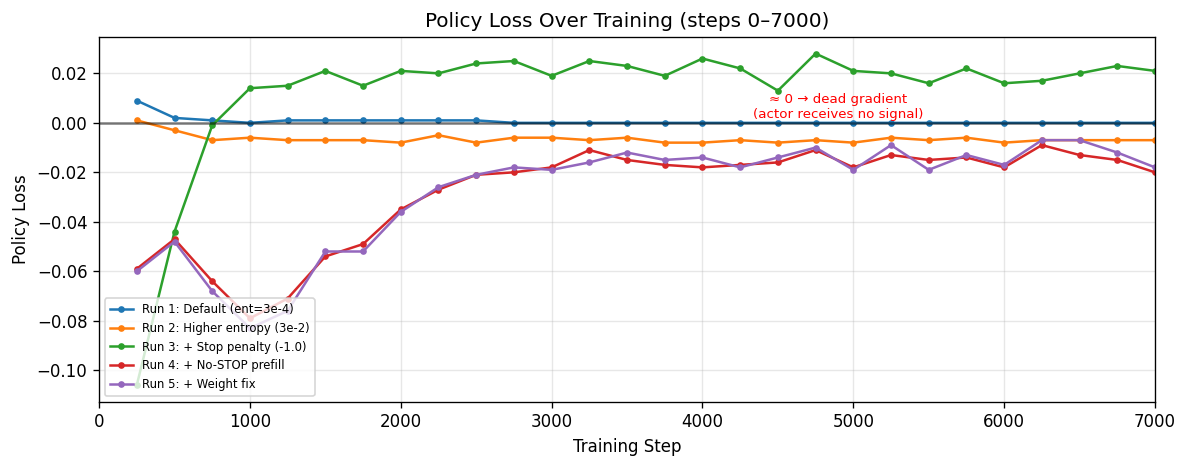

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

for name, d in data.items():
    losses = d["losses"]
    if not losses:
        continue
    steps = [l["step"] for l in losses]
    policy = [l["policy"] for l in losses]
    ax.plot(steps, policy, linewidth=1.5, label=name, marker="o", markersize=3)

ax.axhline(y=0, color="black", linestyle="-", alpha=0.5)
ax.set_xlim(0, MAX_STEP)
ax.set_xlabel("Training Step")
ax.set_ylabel("Policy Loss")
ax.set_title("Policy Loss Over Training (steps 0–7000)")
ax.legend(fontsize=7, loc="lower left")
ax.grid(True, alpha=0.3)

# Annotate the dead gradient zone
ax.annotate("≈ 0 → dead gradient\n(actor receives no signal)",
            xy=(MAX_STEP * 0.7, 0.002), fontsize=8, color="red",
            ha="center")

plt.tight_layout()
plt.show()

## 4. Comparison Table

Summary statistics over the same step range (0–7000) for all runs.

In [7]:
print(f"{'Run':<35s} {'Episodes':>8s} {'% Len-1':>8s} {'Mean Len':>9s} {'FPS':>5s}")
print("-" * 70)
for name, d in data.items():
    eps = d["episodes"]
    losses = d["losses"]
    lengths = [e["ep_steps"] for e in eps]
    pct_1 = sum(1 for l in lengths if l == 1) / len(lengths) * 100 if lengths else 0
    fps = np.mean([l["fps"] for l in losses[-5:]]) if losses else 0
    print(f"{name:<35s} {len(eps):>8d} {pct_1:>7.0f}% {np.mean(lengths):>9.1f} {fps:>5.0f}")

print(f"\nNote: more episodes = shorter episodes (the agent STOPs faster).")
print(f"Runs 4-5 have the most episodes because they collapse earliest.")

Run                                 Episodes  % Len-1  Mean Len   FPS
----------------------------------------------------------------------
Run 1: Default (ent=3e-4)               1648      67%       4.2    17
Run 2: Higher entropy (3e-2)            1816      28%       3.9    17
Run 3: + Stop penalty (-1.0)            2318      42%       3.0    16
Run 4: + No-STOP prefill                4629      83%       1.5    15
Run 5: + Weight fix                     4496      80%       1.6    15

Note: more episodes = shorter episodes (the agent STOPs faster).
Runs 4-5 have the most episodes because they collapse earliest.


## Root Cause Analysis

### Why does the agent always STOP?

Three interacting mechanisms create a self-reinforcing collapse:

1. **Random STOP probability**: With 4 actions and uniform initialization, STOP has 25% probability per step. Even a random policy will call STOP frequently, filling the replay buffer with short episodes.

2. **Dead gradient from continuation weighting**: In R2-Dreamer's imagination, the policy gradient is weighted by `cumprod(cont × disc)`. When STOP → terminal (`cont ≈ 0`), the weight goes to zero, eliminating the gradient signal. The actor receives *no learning signal* for STOP actions — it cannot learn that STOP is bad.

3. **Pessimistic critic trap**: The critic trains on experience dominated by short STOP episodes. It learns that all states have low value. In imagination, non-STOP actions bootstrap from this pessimistic critic, producing returns that look worse than STOP. The actor rationally prefers STOP under these value estimates.

### Attempted fixes and why they failed

| Fix | Mechanism | Why It Failed |
|-----|-----------|---------------|
| Higher entropy (3e-2) | Force exploration via entropy bonus | Prevents full collapse but episodes stay short (~3.5 steps); STOP still fires 25% of the time |
| Stop penalty (-1.0) | Negative reward for unsuccessful STOP | Dead gradient: continuation weight zeros out the penalty signal in imagination |
| No-STOP prefill | Seed buffer with multi-step episodes | Good prefill data gets diluted by STOP episodes once training starts; collapses faster |
| Weight fix (step 0 = 1.0) | Ensure gradient flows for first imagined step | Fixes dead gradient but pessimistic critic still favors STOP |

### Solution: DreamerNav-style STOP

**Make STOP a no-op** (no movement, no episode termination). Episodes end only via:
- Reaching the goal radius (0.1m)
- Exceeding max steps (500)

This eliminates the collapse because:
- STOP no longer triggers `done=True`, so `cont ≈ 1` and gradients flow normally
- STOP gives 0 geodesic delta reward (no movement = no progress), making it naturally suboptimal
- The critic sees full 500-step episodes, learning meaningful value estimates
- Any new terminal action added in the future would face the same dead gradient problem